# Property Distribution Analysis for BACE Dataset

This notebook visualizes the distribution of each computed molecular property.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from pathlib import Path

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## 1. Load Data

In [2]:
# Load all splits
data_dir = Path('../datasets')  # Adjust path if needed

train_data = np.load(data_dir / 'BACE_train.npy', allow_pickle=True).item()
val_data = np.load(data_dir / 'BACE_val.npy', allow_pickle=True).item()
test_data = np.load(data_dir / 'BACE_test.npy', allow_pickle=True).item()
stats = np.load(data_dir / 'BACE_stats.npy', allow_pickle=True).item()

print(f"Train: {len(train_data)} molecules")
print(f"Val: {len(val_data)} molecules")
print(f"Test: {len(test_data)} molecules")
print(f"\nProperties computed: {list(stats.keys())}")

Train: 829 molecules
Val: 276 molecules
Test: 277 molecules

Properties computed: ['qed', 'HeavyAtomMolWt', 'MolWt', 'TPSA', 'MolLogP', 'SAS', 'BalabanJ', 'BertzCT', 'FSP3']


In [3]:
# Combine all data into a DataFrame
def data_to_df(data_dict, split_name):
    rows = []
    for smiles, props in data_dict.items():
        row = {'smiles': smiles, 'split': split_name}
        row.update(props)
        rows.append(row)
    return pd.DataFrame(rows)

df_train = data_to_df(train_data, 'train')
df_val = data_to_df(val_data, 'val')
df_test = data_to_df(test_data, 'test')

df_all = pd.concat([df_train, df_val, df_test], ignore_index=True)
print(f"Total molecules: {len(df_all)}")
df_all.head()

Total molecules: 1382


,smiles,split,qed,HeavyAtomMolWt,MolWt,TPSA,MolLogP,SAS,BalabanJ,BertzCT,FSP3,bace_activity
0,Fc1cc(cc(F)c1)C[C@H](NC(=O)C)[C@H](O)C[NH2+]C1...,train,0.470261,436.279,467.527,65.94,3.1683,4.260820,1.719527,971.872247,0.480000,0.0
1,O=C1N(CC[C@]12[N@H+](CCC2)CCC)[C@H](C(=O)N[C@H...,train,0.304112,500.388,550.788,90.69,1.4101,5.587909,1.398189,1123.688444,0.575758,1.0
2,Fc1cc(cc(F)c1)CC(NC(=O)C)C(O)C[NH2+]C1(CCC(CC1...,train,0.489423,446.327,485.639,65.94,4.2595,4.240779,1.829581,1030.637563,0.482759,1.0
3,O=C1N(C)C(=N[C@@]1(c1cc(ccc1)-c1cncnc1)c1cc(nc...,train,0.756573,352.272,372.432,97.36,2.1313,3.256134,1.945116,1065.255665,0.190476,1.0
4,S1(=O)(=O)N(C2(CC([NH+](CC2)Cc2cc(OC(C)C)ccc2)...,train,0.534395,493.394,526.658,80.07,2.9805,5.099590,1.446837,1356.912282,0.407407,0.0


## 2. Summary Statistics

In [4]:
# Get property columns (exclude smiles, split, bace_activity)
property_cols = [col for col in df_all.columns if col not in ['smiles', 'split', 'bace_activity']]
print(f"Properties to analyze: {property_cols}")

# Summary statistics
df_all[property_cols].describe().round(3)

Properties to analyze: ['qed', 'HeavyAtomMolWt', 'MolWt', 'TPSA', 'MolLogP', 'SAS', 'BalabanJ', 'BertzCT', 'FSP3']


,qed,HeavyAtomMolWt,MolWt,TPSA,MolLogP,SAS,BalabanJ,BertzCT,FSP3
count,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000,1382.000
mean,0.520,451.394,482.348,95.640,3.139,3.937,1.731,1163.955,0.369
std,0.243,112.537,122.222,33.259,1.241,0.807,0.313,310.302,0.154
min,0.017,126.094,138.190,16.610,-6.457,1.673,1.159,192.917,0.000
25%,0.308,370.306,390.435,72.940,2.433,3.354,1.544,961.251,0.250
50%,0.508,438.248,465.432,91.180,3.169,3.931,1.716,1112.816,0.364
75%,0.746,526.419,566.731,110.180,3.876,4.374,1.873,1352.331,0.486
max,0.947,1262.799,1350.495,525.060,7.070,6.805,5.479,3595.006,0.880


In [5]:
# Check for NaN values
nan_counts = df_all[property_cols].isna().sum()
print("NaN counts per property:")
print(nan_counts[nan_counts > 0] if nan_counts.sum() > 0 else "No NaN values!")

NaN counts per property:
No NaN values!


## 3. Distribution Histograms (All Data)

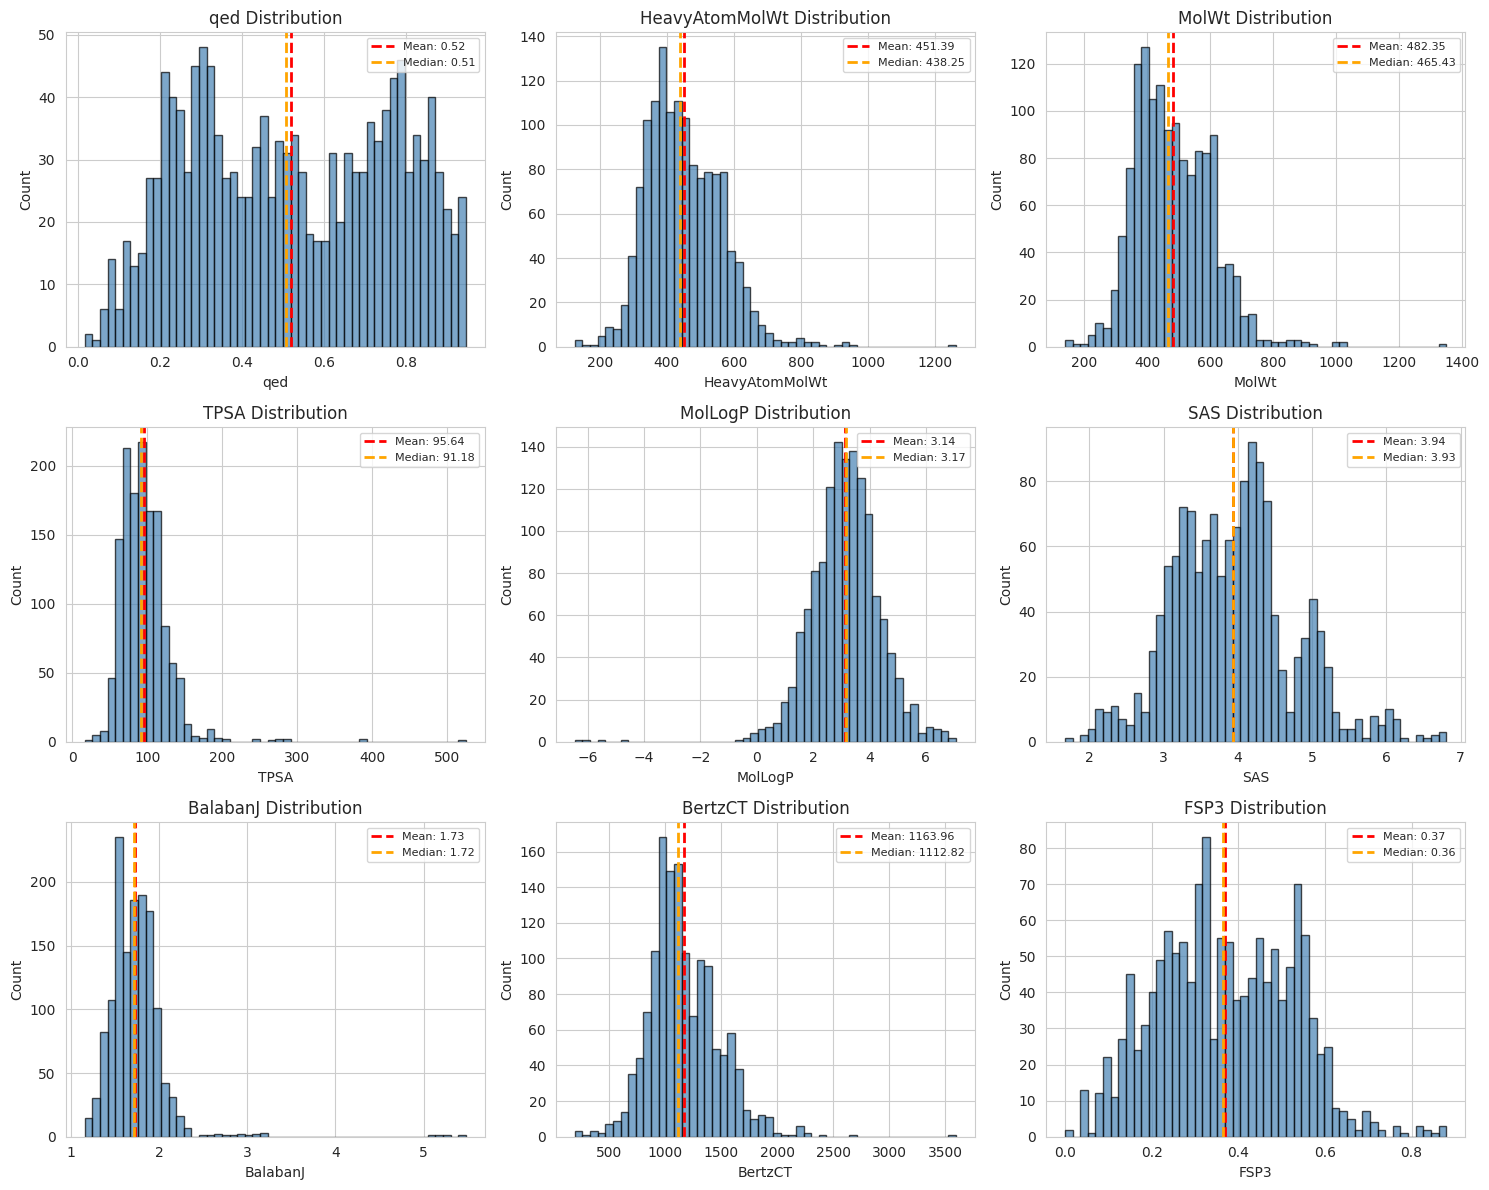

In [6]:
n_props = len(property_cols)
n_cols = 3
n_rows = (n_props + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

for i, prop in enumerate(property_cols):
    ax = axes[i]
    values = df_all[prop].dropna()
    
    ax.hist(values, bins=50, edgecolor='black', alpha=0.7, color='steelblue')
    ax.axvline(values.mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {values.mean():.2f}')
    ax.axvline(values.median(), color='orange', linestyle='--', linewidth=2, label=f'Median: {values.median():.2f}')
    
    ax.set_xlabel(prop)
    ax.set_ylabel('Count')
    ax.set_title(f'{prop} Distribution')
    ax.legend(fontsize=8)

# Hide empty subplots
for i in range(n_props, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('figures/property_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Distribution by Split (Train/Val/Test)

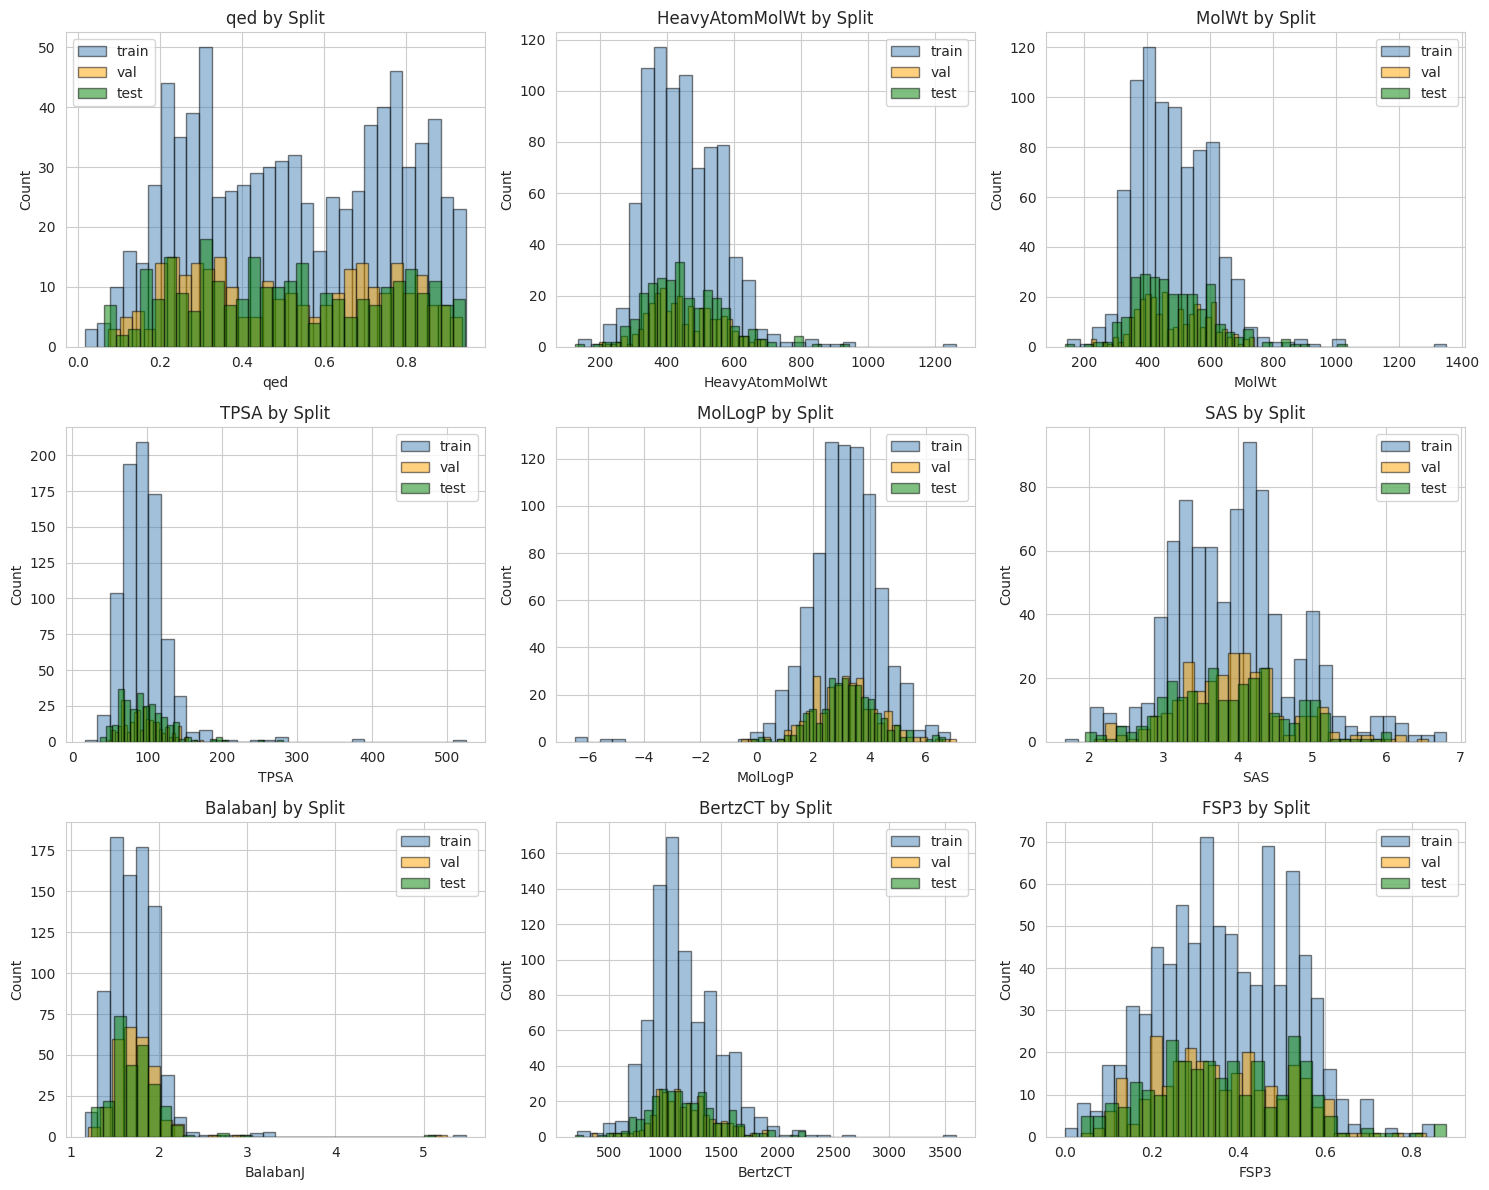

In [7]:
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 4 * n_rows))
axes = axes.flatten()

colors = {'train': 'steelblue', 'val': 'orange', 'test': 'green'}

for i, prop in enumerate(property_cols):
    ax = axes[i]
    
    for split in ['train', 'val', 'test']:
        values = df_all[df_all['split'] == split][prop].dropna()
        ax.hist(values, bins=30, alpha=0.5, label=split, color=colors[split], edgecolor='black')
    
    ax.set_xlabel(prop)
    ax.set_ylabel('Count')
    ax.set_title(f'{prop} by Split')
    ax.legend()

for i in range(n_props, len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.savefig('figures/property_distributions_by_split.png', dpi=150, bbox_inches='tight')
plt.show()

## 10. Summary Table

In [8]:
# Create summary table with stats from file vs computed
summary_rows = []
for prop in property_cols:
    values = df_all[prop].dropna()
    row = {
        'Property': prop,
        'Count': len(values),
        'Mean': values.mean(),
        'Std': values.std(),
        'Min': values.min(),
        'Max': values.max(),
        'Skewness': values.skew(),
        'Kurtosis': values.kurtosis(),
    }
    # Add stats from file if available
    if prop in stats:
        row['Stats_Mean'] = stats[prop]['mean']
        row['Stats_Std'] = stats[prop]['std']
    summary_rows.append(row)

summary_df = pd.DataFrame(summary_rows)
summary_df.round(3)

,Property,Count,Mean,Std,Min,Max,Skewness,Kurtosis,Stats_Mean,Stats_Std
0,qed,1382,0.520,0.243,0.017,0.947,0.021,-1.256,0.520,0.242
1,HeavyAtomMolWt,1382,451.394,112.537,126.094,1262.799,0.833,2.647,451.394,112.496
2,MolWt,1382,482.348,122.222,138.190,1350.495,0.821,2.471,482.348,122.178
3,TPSA,1382,95.640,33.259,16.610,525.060,3.502,30.948,95.640,33.247
4,MolLogP,1382,3.139,1.241,-6.457,7.070,-0.953,7.389,3.139,1.240
5,SAS,1382,3.937,0.807,1.673,6.805,0.401,0.442,3.937,0.807
6,BalabanJ,1382,1.731,0.313,1.159,5.479,4.682,47.006,1.731,0.312
7,BertzCT,1382,1163.955,310.302,192.917,3595.006,0.867,3.438,1163.955,310.190
8,FSP3,1382,0.369,0.154,0.000,0.880,0.159,-0.372,0.369,0.154


In [9]:
# Save summary to CSV
summary_df.to_csv('property_summary.csv', index=False)
print("Saved summary to property_summary.csv")

Saved summary to property_summary.csv
